In [6]:
#Loads the NuScenes dataset for further processing.
from nuscenes.nuscenes import NuScenes
from sklearn.model_selection import train_test_split
import numpy as np
import json
import os
import pandas as pd
import random
from tqdm import tqdm

# Load the full trainval set
nusc = NuScenes(version='v1.0-trainval', dataroot='/data/sets/nuscenes', verbose=True)


Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 40.059 seconds.
Reverse indexing ...
Done reverse indexing in 6.6 seconds.


In [7]:
# Selects a subset of scenes and splits them into train/val/test for data preparation.
all_scenes = nusc.scene.copy()

selected_scenes = all_scenes[:1000]  # Now here i give all scenes: to give 20 to 30 need to write [20:30]
from sklearn.model_selection import train_test_split

train_scenes, temp_scenes = train_test_split(selected_scenes, test_size=0.3, random_state=42)
val_scenes, test_scenes = train_test_split(temp_scenes, test_size=0.4, random_state=42)

In [8]:
#Defines a helper function to calculate object velocity using instance annotations.
def get_instance_velocity(nusc, instance_token, current_ann_token):
    try:
        instance = nusc.get('instance', instance_token)
        annotations = instance.get('anns', [])
        if current_ann_token not in annotations:
            return np.zeros(3)
        curr_idx = annotations.index(current_ann_token)
        if curr_idx == 0:
            return np.zeros(3)
        prev_ann_token = annotations[curr_idx - 1]
        curr_ann = nusc.get('sample_annotation', current_ann_token)
        prev_ann = nusc.get('sample_annotation', prev_ann_token)
        t1 = np.array(prev_ann['translation'])
        t2 = np.array(curr_ann['translation'])
        dt = (curr_ann['timestamp'] - prev_ann['timestamp']) * 1e-6
        if dt == 0:
            return np.zeros(3)
        return (t2 - t1) / dt
    except:
        return np.zeros(3)


In [9]:
#Processes each scene to compute risk metrics (TTC, relative speed, ego speed) and labels frames with a risk level.
import os
import pandas as pd
from tqdm import tqdm
import numpy as np

def process_scenes(scene_list, split_name="train", save_dir="./nuscenes_output"):
    os.makedirs(save_dir, exist_ok=True)
    data_rows = []

    for scene in tqdm(scene_list, desc=f"Processing {split_name} scenes"):
        scene_token = scene['token']
        sample_token = scene['first_sample_token']
        
        while sample_token:
            sample = nusc.get('sample', sample_token)
            timestamp = sample['timestamp']
            lidar_token = sample['data']['LIDAR_TOP']
            lidar_data = nusc.get('sample_data', lidar_token)
            ego_pose = nusc.get('ego_pose', lidar_data['ego_pose_token'])
            ego_translation = np.array(ego_pose['translation'])

            # Calculate ego velocity
            ego_velocity = np.zeros(3)
            if lidar_data['prev']:
                prev_lidar_data = nusc.get('sample_data', lidar_data['prev'])
                prev_pose = nusc.get('ego_pose', prev_lidar_data['ego_pose_token'])
                dt = (lidar_data['timestamp'] - prev_lidar_data['timestamp']) * 1e-6
                if dt > 0:
                    ego_velocity = (np.array(ego_pose['translation']) - np.array(prev_pose['translation'])) / dt
            ego_speed = np.linalg.norm(ego_velocity)

            # Find moving objects
            moving_objects = []
            for ann_token in sample['anns']:
                ann = nusc.get('sample_annotation', ann_token)
                instance_token = ann['instance_token']
                object_translation = np.array(ann['translation'])
                distance = np.linalg.norm(object_translation - ego_translation)
                object_velocity = get_instance_velocity(nusc, instance_token, ann_token)
                rel_velocity = np.linalg.norm(object_velocity - ego_velocity)
                ttc = distance / rel_velocity if rel_velocity > 0 else float('inf')

                if rel_velocity > 0.5:  # Filter moving objects
                    category = ann['category_name']
                    attribute = nusc.get('attribute', ann['attribute_tokens'][0])['name'] if ann['attribute_tokens'] else 'None'
                    moving_objects.append({
                        'category': category,
                        'distance': distance,
                        'rel_velocity': rel_velocity,
                        'ttc': ttc,
                        'attribute': attribute
                    })

            moving_objects = sorted(moving_objects, key=lambda x: x['distance'])[:2]

            # Pad if fewer than 2
            while len(moving_objects) < 2:
                moving_objects.append({
                    'category': 'None',
                    'distance': 0.0,
                    'rel_velocity': 0.0,
                    'ttc': float('inf'),
                    'attribute': 'None'
                })

            # Assign risk level
            risk_level = 'low'
            closest_ttc = moving_objects[0]['ttc']
            if closest_ttc < 1.5:
                risk_level = 'high'
            elif 1.5 <= closest_ttc <= 3.0:
                risk_level = 'medium'

            data_rows.append({
                'timestamp': timestamp,
                'scene_token': scene_token,
                'sample_token': sample_token,
                'ego_speed': round(ego_speed, 2),
                'object_1_ttc': round(moving_objects[0]['ttc'], 2),
                'object_2_ttc': round(moving_objects[1]['ttc'], 2),
                'risk_level': risk_level
            })

            sample_token = sample['next']
    
    df = pd.DataFrame(data_rows)
    csv_path = os.path.join(save_dir, f"nuscenes_risk_{split_name}.csv")
    df.to_csv(csv_path, index=False)
    print(f"✅ Saved {split_name} CSV to {csv_path}")
    return df
 

In [10]:
# Generates train/val/test CSV files and a merged dataset for model training and evaluation.
df_train = process_scenes(train_scenes, "train")
df_val = process_scenes(val_scenes, "val")
df_test = process_scenes(test_scenes, "test")

# Save DataFrames as CSV
df_train.to_csv("train.csv", index=False)
df_val.to_csv("val.csv", index=False)
df_test.to_csv("test.csv", index=False)

# Save combined flat file
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_all.to_csv("nuscenes_risk_all.csv", index=False)
print("✅ Saved: train.csv, val.csv, test.csv, nuscenes_risk_all.csv and their JSON sequences.")


Processing train scenes: 100%|███████████████████████████████████████████████████████| 595/595 [00:07<00:00, 79.52it/s]


✅ Saved train CSV to ./nuscenes_output\nuscenes_risk_train.csv


Processing val scenes: 100%|█████████████████████████████████████████████████████████| 153/153 [00:01<00:00, 80.81it/s]


✅ Saved val CSV to ./nuscenes_output\nuscenes_risk_val.csv


Processing test scenes: 100%|████████████████████████████████████████████████████████| 102/102 [00:01<00:00, 78.29it/s]


✅ Saved test CSV to ./nuscenes_output\nuscenes_risk_test.csv
✅ Saved: train.csv, val.csv, test.csv, nuscenes_risk_all.csv and their JSON sequences.


In [11]:
#Generates labeled time-series sequences from tabular data for training a prediction model.
def generate_sequences(df, output_json):
    sequence_length = 5
    sequence_inputs = []
    sequence_labels = []
    
    grouped = df.groupby('scene_token')
    for _, group in grouped:
        group = group.sort_values('timestamp').reset_index(drop=True)
        for i in range(len(group) - sequence_length):
            sequence = group.iloc[i:i + sequence_length]
            next_risk = group.iloc[i + sequence_length]['risk_level']
            ttc1_seq = sequence['object_1_ttc'].values
            ttc2_seq = sequence['object_2_ttc'].values
            ego_seq = sequence['ego_speed'].values

            input_seq = np.stack([ttc1_seq, ttc2_seq, ego_seq], axis=1)
            sequence_inputs.append(input_seq.tolist())
            sequence_labels.append(next_risk)
    
    with open(output_json, "w") as f:
        json.dump({"inputs": sequence_inputs, "labels": sequence_labels}, f)
    
    print(f"✅ Saved {len(sequence_inputs)} sequences to {output_json}")
 

In [12]:
# Creates JSON files with input sequences and labels for all dataset splits.
generate_sequences(df_train, "sequences_train.json")
generate_sequences(df_val, "sequences_val.json")
generate_sequences(df_test, "sequences_test.json")


✅ Saved 20920 sequences to sequences_train.json
✅ Saved 5383 sequences to sequences_val.json
✅ Saved 3596 sequences to sequences_test.json


In [13]:
#Loads and encodes training data for model input.
import json
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load from JSON
with open("sequences_train.json", "r") as f:
    train_data = json.load(f)

X_train = np.array(train_data["inputs"])
y_train = np.array(train_data["labels"])

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)

# Print shapes and class names
print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ y_train shape: {y_train_enc.shape}")
print(f"✅ Label classes: {label_encoder.classes_}")



✅ X_train shape: (20920, 5, 3)
✅ y_train shape: (20920,)
✅ Label classes: ['high' 'low' 'medium']


In [14]:
#Prepares the full dataset with one-hot encoded labels for training a classification model.

import json
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

def load_sequences(path):
    with open(path, 'r') as f:
        data = json.load(f)
    X = np.array(data['inputs'])  # shape: (num_samples, 5, 3)
    y = np.array(data['labels'])  # shape: (num_samples,)
    return X, y

# Load training, validation, test data
X_train, y_train = load_sequences("sequences_train.json")
X_val, y_val = load_sequences("sequences_val.json")
X_test, y_test = load_sequences("sequences_test.json")

# Encode labels (low/medium/high → 0/1/2)
label_encoder = LabelEncoder()
y_train_enc = to_categorical(label_encoder.fit_transform(y_train))
y_val_enc = to_categorical(label_encoder.transform(y_val))
y_test_enc = to_categorical(label_encoder.transform(y_test))


C:\Users\$8CUJ00-BGKRQC8B3RAL\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 10, 512)             │         538,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 10, 512)             │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 10, 256)             │         656,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 10, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,388,675 (5.30 MB)

 Trainable params: 1,386,499 (5.29 MB)

...

207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8895 - loss: 0.3156 - val_accuracy: 0.8852 - val_loss: 0.3090 - learning_rate: 2.0000e-04
Epoch 41/55
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8909 - loss: 0.3228

207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8909 - loss: 0.3228 - val_accuracy: 0.8894 - val_loss: 0.3001 - learning_rate: 2.0000e-04
Epoch 42/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8951 - loss: 0.3136 - val_accuracy: 0.8880 - val_loss: 0.3127 - learning_rate: 2.0000e-04
Epoch 43/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.8957 - loss: 0.3144 - val_accuracy: 0.8859 - val_loss: 0.3199 - learning_rate: 2.0000e-04
Epoch 44/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.8973 - loss: 0.3007 - val_accuracy: 0.8845 - val_loss: 0.3022 - learning_rate: 2.0000e-04
Epoch 45/55
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8945 - loss: 0.3121

207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8945 - loss: 0.3121 - val_accuracy: 0.9007 - val_loss: 0.2827 - learning_rate: 2.0000e-04
Epoch 46/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.8942 - loss: 0.3152 - val_accuracy: 0.8884 - val_loss: 0.3081 - learning_rate: 2.0000e-04
Epoch 47/55
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8914 - loss: 0.3018

207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8914 - loss: 0.3018 - val_accuracy: 0.8976 - val_loss: 0.2803 - learning_rate: 2.0000e-04
Epoch 48/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8935 - loss: 0.3051 - val_accuracy: 0.8820 - val_loss: 0.3108 - learning_rate: 2.0000e-04
Epoch 49/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.8911 - loss: 0.3104 - val_accuracy: 0.8845 - val_loss: 0.3219 - learning_rate: 2.0000e-04
Epoch 50/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.8918 - loss: 0.3084 - val_accuracy: 0.8693 - val_loss: 0.3528 - learning_rate: 2.0000e-04
Epoch 51/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.8949 - loss: 0.2919 - val_accuracy: 0.8933 - val_loss: 0.2853 - learning_rate: 2.0000e-04
Epoch 52/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.8942 - loss: 0.3045 - val_accuracy: 0.8923 - val_loss: 0.2859 - learning_rate: 2.0000e-04
Epoch 53/55
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - ac

207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.8954 - loss: 0.2962 - val_accuracy: 0.8965 - val_loss: 0.2748 - learning_rate: 4.0000e-05
Epoch 54/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.9068 - loss: 0.2745 - val_accuracy: 0.8944 - val_loss: 0.2818 - learning_rate: 4.0000e-05
Epoch 55/55
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.9002 - loss: 0.2813 - val_accuracy: 0.8940 - val_loss: 0.2767 - learning_rate: 4.0000e-05
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9043 - loss: 0.2573

Test Accuracy: 90.85%


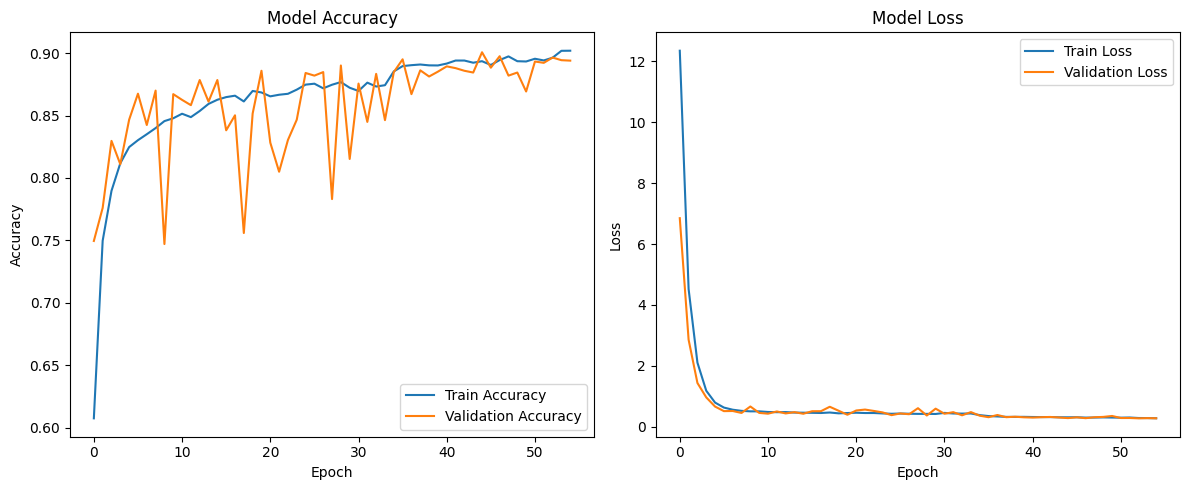

Model saved as risk_prediction_model.h5


In [15]:
# Load and preprocess data
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load dataset
df_all = pd.read_csv("nuscenes_risk_all.csv")

# Feature engineering with NaN/Inf-safe operations
def add_features(df):
    df['ttc_diff'] = df['object_1_ttc'] - df['object_2_ttc']

    df['rel_speed_ratio'] = df['object_1_ttc'] / (df['object_2_ttc'].replace(0, np.nan) + 1e-5)
    df['rel_speed_ratio'] = df['rel_speed_ratio'].replace([np.inf, -np.inf], np.nan)

    df['danger_indicator'] = np.where(
        (df['object_1_ttc'] < 3) | (df['object_2_ttc'] < 3), 1, 0
    )

    df['speed_category'] = pd.cut(
        df['ego_speed'],
        bins=[0, 5, 15, 30, 100],
        labels=['stationary', 'slow', 'medium', 'fast']
    )

    return df

# Apply features
df_all = add_features(df_all)

# Drop rows with NaNs
df_all = df_all.dropna().reset_index(drop=True)

# Feature selection
features = df_all[[
    'object_1_ttc',
    'object_2_ttc',
    'ego_speed',
    'ttc_diff',
    'rel_speed_ratio',
    'danger_indicator'
]]

# Encode labels AFTER dropna
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df_all['risk_level'])

# Handle class imbalance
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))

# Create sequences
sequence_length = 10
X_sequences = []
y_sequences = []

scene_tokens = df_all['scene_token'].values
timestamps = df_all['timestamp'].values
feature_values = features.values
label_values = labels

for scene_token in np.unique(scene_tokens):
    indices = np.where(scene_tokens == scene_token)[0]
    sorted_indices = indices[np.argsort(timestamps[indices])]

    for i in range(len(sorted_indices) - sequence_length):
        idx_slice = sorted_indices[i:i + sequence_length]
        target_idx = sorted_indices[i + sequence_length]

        seq = feature_values[idx_slice]
        label = label_values[target_idx]

        if not np.isnan(seq).any() and not np.isinf(seq).any():
            X_sequences.append(seq)
            y_sequences.append(label)

X = np.array(X_sequences)
y = np.array(y_sequences)

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Normalize features safely
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_reshaped)

def scale_data(data):
    shape = data.shape
    reshaped = data.reshape(-1, shape[-1])
    reshaped = np.nan_to_num(reshaped, nan=0.0, posinf=0.0, neginf=0.0)
    scaled = scaler.transform(reshaped)
    return scaled.reshape(shape)

X_train_scaled = scale_data(X_train)
X_val_scaled = scale_data(X_val)
X_test_scaled = scale_data(X_test)

# One-hot encode labels
y_train_enc = to_categorical(y_train)
y_val_enc = to_categorical(y_val)
y_test_enc = to_categorical(y_test)

# Build the model
def create_model(input_shape, num_classes):
    model = Sequential([
        Bidirectional(
            LSTM(256, return_sequences=True, kernel_regularizer=l2(0.01)),
            input_shape=input_shape
        ),
        BatchNormalization(),
        Dropout(0.4),

        Bidirectional(
            LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01))
        ),
        BatchNormalization(),
        Dropout(0.4),

        Bidirectional(
            LSTM(64, kernel_regularizer=l2(0.01))
        ),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.5),

        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    optimizer = Adam(learning_rate=0.001, clipvalue=0.5)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Model parameters
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
num_classes = y_train_enc.shape[1]
model = create_model(input_shape, num_classes)
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

# Train the model
history = model.fit(
    X_train_scaled, y_train_enc,
    validation_data=(X_val_scaled, y_val_enc),
    epochs=55,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks
)

# Evaluate the model
model.load_weights('best_model.h5')
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_enc)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

# Save final model
model.save('risk_prediction_model.h5')
print("Model saved as risk_prediction_model.h5")


In [16]:
import joblib

# Assuming you already have:
# scaler fitted on training features
# label_encoder fitted on all labels

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved to scaler.pkl")

# Save label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Label encoder saved to label_encoder.pkl")


Scaler saved to scaler.pkl
Label encoder saved to label_encoder.pkl


In [1]:
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('risk_prediction_model.h5')

# Load scaler and label encoder
scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')

# Feature engineering function (must match training)
def add_features(df):
    df['ttc_diff'] = df['object_1_ttc'] - df['object_2_ttc']
    df['rel_speed_ratio'] = df['object_1_ttc'] / (df['object_2_ttc'].replace(0, np.nan) + 1e-5)
    df['rel_speed_ratio'] = df['rel_speed_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
    df['danger_indicator'] = ((df['object_1_ttc'] < 3) | (df['object_2_ttc'] < 3)).astype(int)
    return df

# Prepare input data for prediction: normalize and reshape
def preprocess_sequence(window_df):
    # Select features in same order used in training
    feature_cols = [
        'object_1_ttc', 'object_2_ttc', 'ego_speed',
        'ttc_diff', 'rel_speed_ratio', 'danger_indicator'
    ]
    df_feat = window_df[feature_cols].copy()
    
    # Handle missing or infinite values
    df_feat = df_feat.fillna(0).replace([np.inf, -np.inf], 0)
    
    # Scale features
    scaled_features = scaler.transform(df_feat.values)
    
    # Reshape to (1, seq_len, num_features)
    return np.expand_dims(scaled_features, axis=0)

def predict_risk_for_frame(frame_index, df_flat, model, label_encoder, sequence_length=5):
    """
    Predict risk level at frame_index using previous sequence_length frames.
    """
    if frame_index < sequence_length:
        raise ValueError(f"Need at least {sequence_length} previous frames. Start from frame_index = {sequence_length} or higher.")
    
    # Add features first
    df_flat = add_features(df_flat)
    
    # Extract previous frames for sequence
    window = df_flat.iloc[frame_index - sequence_length: frame_index]
    
    print("🔍 Using these frames for prediction:")
    print(window[['timestamp', 'object_1_ttc', 'object_2_ttc', 'ego_speed', 'risk_level']])
    
    # Preprocess input sequence
    input_seq = preprocess_sequence(window)
    
    # Predict
    pred_probs = model.predict(input_seq)
    pred_class = np.argmax(pred_probs, axis=1)
    pred_label = label_encoder.inverse_transform(pred_class)[0]
    
    print(f"\n🧠 Predicted Risk Level at frame {frame_index}: {pred_label}")
    return pred_label

# Testing:
if __name__ == "__main__":
    # Load your test data csv - this must have same columns used in training + risk_level column
    df_test_flat = pd.read_csv('nuscenes_risk_test.csv')
    
    # Predict risk at a specific frame index (e.g. 23)
    predicted_risk = predict_risk_for_frame(473, df_test_flat, model, label_encoder)


🔍 Using these frames for prediction:
            timestamp  object_1_ttc  object_2_ttc  ego_speed risk_level
468  1542800559197751          0.98          1.07       5.98       high
469  1542800559697623          0.63          1.31       6.38       high
470  1542800560197555          0.58          1.62       7.03       high
471  1542800560697924          0.89          2.04       7.25       high
472  1542800561197815          1.31          1.98       7.46       high
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step

🧠 Predicted Risk Level at frame 473: medium


🔢 Total Predicted Risk Levels:
Counter({'high': 2299, 'medium': 1395, 'low': 407})


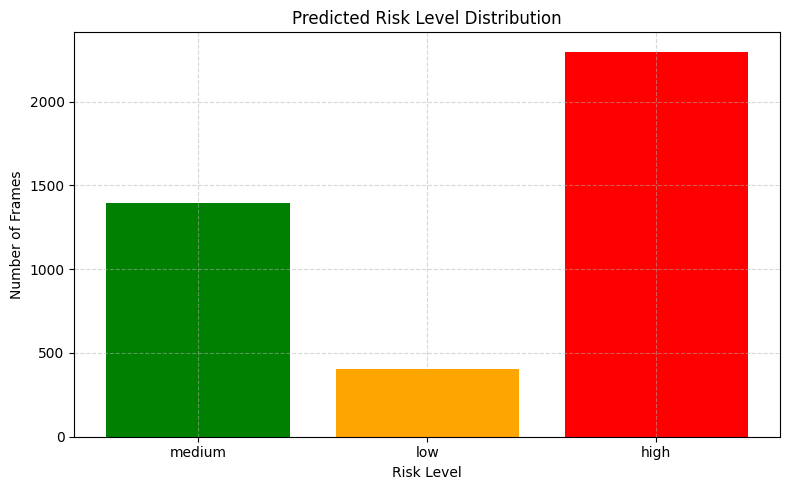

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from collections import Counter

# Load trained model and tools
model = load_model('risk_prediction_model.h5')
scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')

# Add same features used during training
def add_features(df):
    df['ttc_diff'] = df['object_1_ttc'] - df['object_2_ttc']
    df['rel_speed_ratio'] = df['object_1_ttc'] / (df['object_2_ttc'].replace(0, np.nan) + 1e-5)
    df['rel_speed_ratio'] = df['rel_speed_ratio'].replace([np.inf, -np.inf], 0).fillna(0)
    df['danger_indicator'] = ((df['object_1_ttc'] < 3) | (df['object_2_ttc'] < 3)).astype(int)
    return df

# Preprocess single sequence
def preprocess_sequence(window_df):
    feature_cols = [
        'object_1_ttc', 'object_2_ttc', 'ego_speed',
        'ttc_diff', 'rel_speed_ratio', 'danger_indicator'
    ]
    df_feat = window_df[feature_cols].copy().fillna(0).replace([np.inf, -np.inf], 0)
    scaled = scaler.transform(df_feat.values)
    return np.expand_dims(scaled, axis=0)

# Predict all frame-level risk levels (rolling window)
def predict_all_risks(df, sequence_length=5):
    df = add_features(df)
    predictions = []
    
    for i in range(sequence_length, len(df)):
        window = df.iloc[i-sequence_length:i]
        input_seq = preprocess_sequence(window)
        pred = model.predict(input_seq, verbose=0)
        pred_class = np.argmax(pred)
        pred_label = label_encoder.inverse_transform([pred_class])[0]
        predictions.append(pred_label)
    
    return predictions

# Load your test file
df_test = pd.read_csv('nuscenes_risk_test.csv')
predicted_risks = predict_all_risks(df_test)

# Count and plot
risk_counts = Counter(predicted_risks)
print("🔢 Total Predicted Risk Levels:")
print(risk_counts)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(risk_counts.keys(), risk_counts.values(), color=['green', 'orange', 'red'])
plt.title("Predicted Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Frames")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("predicted_risk_distribution.png")
plt.show()


C:\Users\$8CUJ00-BGKRQC8B3RAL\AppData\Local\Temp\ipykernel_21704\2885127974.py:65: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  plt.tight_layout()
C:\Users\$8CUJ00-BGKRQC8B3RAL\AppData\Local\Temp\ipykernel_21704\2885127974.py:66: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  plt.savefig(f"risk_plot_{risk}_{idx + 1}.png")
C:\ProgramData\anaconda3\envs\nuscenes_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


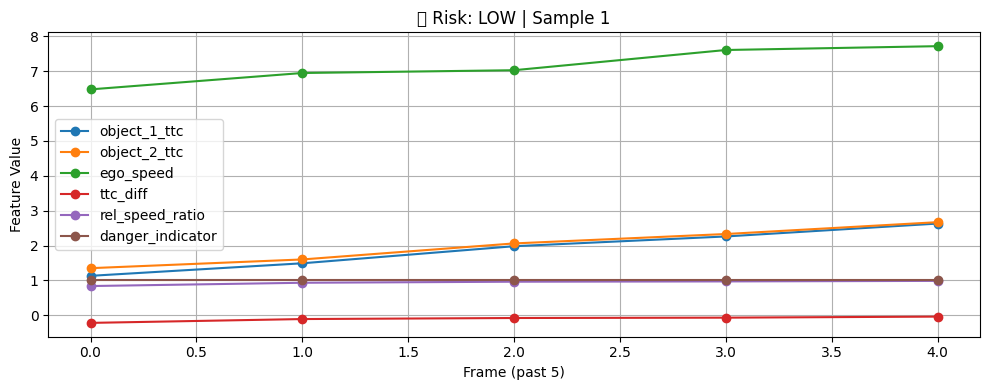

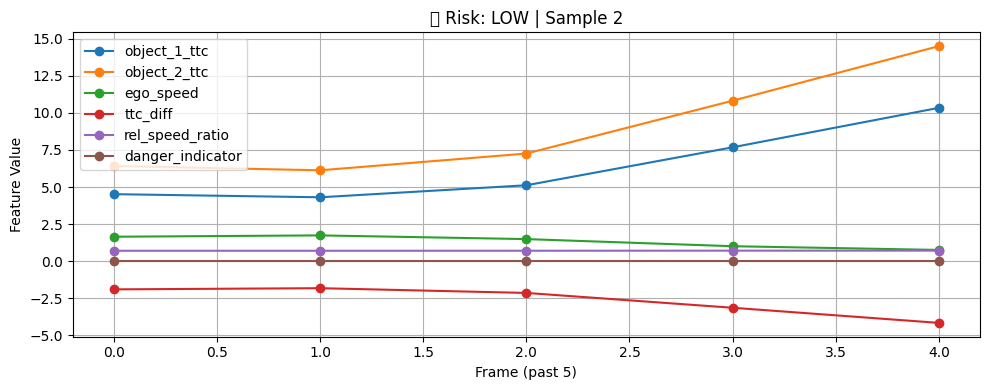

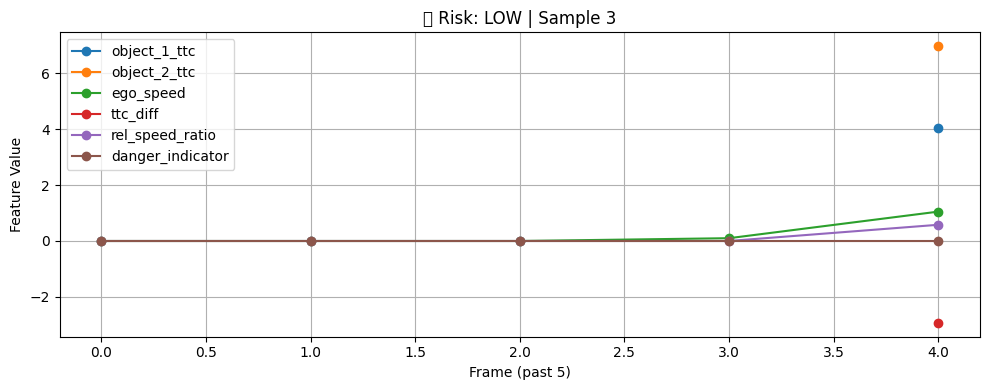

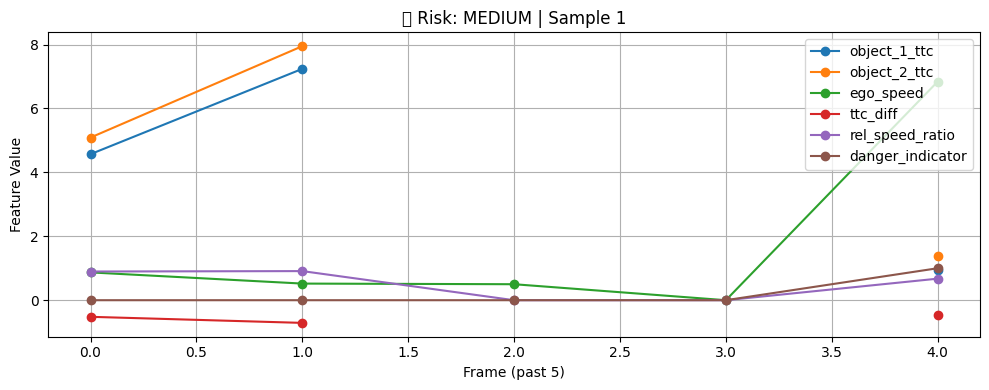

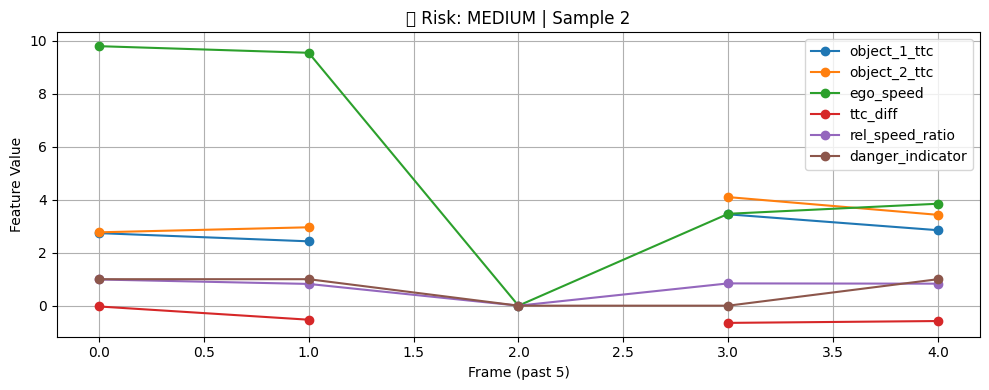

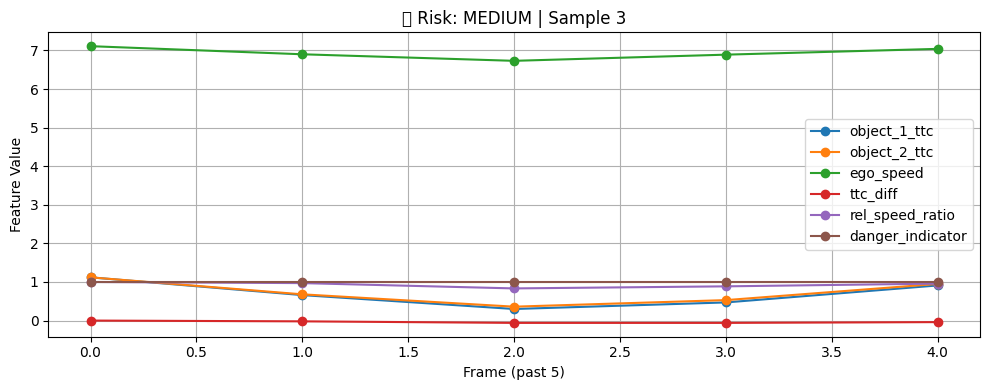

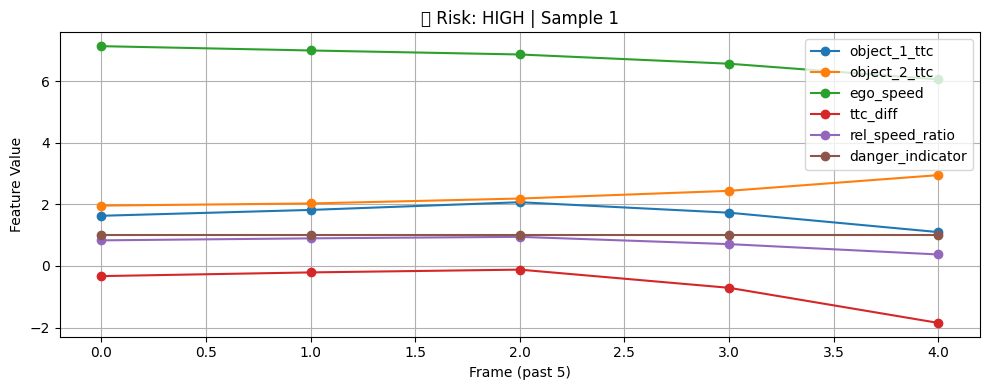

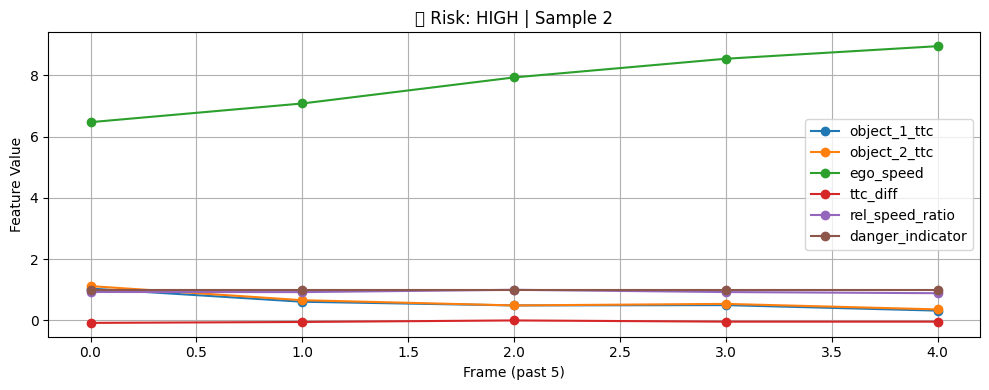

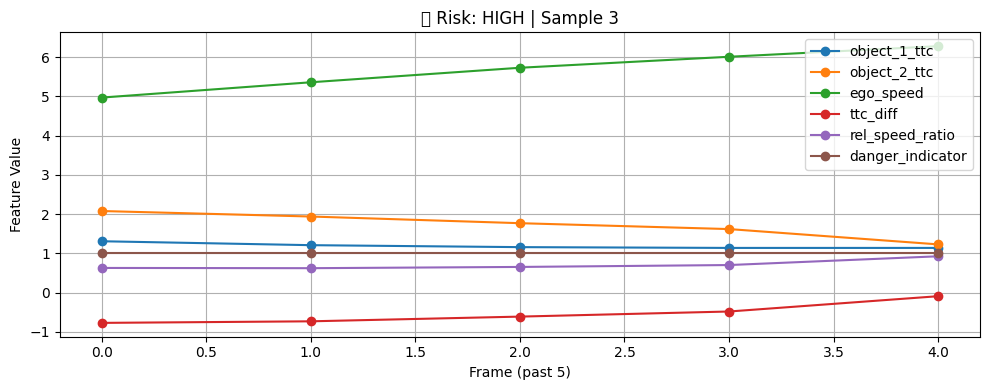

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
import random

# Load model, scaler, encoder
model = load_model('risk_prediction_model.h5')
scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')

# Feature engineering
def add_features(df):
    df['ttc_diff'] = df['object_1_ttc'] - df['object_2_ttc']
    df['rel_speed_ratio'] = df['object_1_ttc'] / (df['object_2_ttc'].replace(0, np.nan) + 1e-5)
    df['rel_speed_ratio'] = df['rel_speed_ratio'].replace([np.inf, -np.inf], 0).fillna(0)
    df['danger_indicator'] = ((df['object_1_ttc'] < 3) | (df['object_2_ttc'] < 3)).astype(int)
    return df

# Preprocess
def preprocess_sequence(window_df):
    feature_cols = [
        'object_1_ttc', 'object_2_ttc', 'ego_speed',
        'ttc_diff', 'rel_speed_ratio', 'danger_indicator'
    ]
    df_feat = window_df[feature_cols].copy().fillna(0).replace([np.inf, -np.inf], 0)
    scaled = scaler.transform(df_feat.values)
    return np.expand_dims(scaled, axis=0), window_df[feature_cols]

# Predict and store raw sequences
def collect_risk_sequences(df, sequence_length=5):
    df = add_features(df)
    data_by_risk = {'low': [], 'medium': [], 'high': []}

    for i in range(sequence_length, len(df)):
        window = df.iloc[i-sequence_length:i]
        input_seq, raw_feats = preprocess_sequence(window)
        pred = model.predict(input_seq, verbose=0)
        pred_class = np.argmax(pred)
        pred_label = label_encoder.inverse_transform([pred_class])[0]
        data_by_risk[pred_label].append(raw_feats.reset_index(drop=True))
    
    return data_by_risk

# Load and predict
df_test = pd.read_csv('nuscenes_risk_test.csv')
risk_sequences = collect_risk_sequences(df_test)

# Randomly plot 3 examples per class
risk_levels = ['low', 'medium', 'high']
features = ['object_1_ttc', 'object_2_ttc', 'ego_speed', 'ttc_diff', 'rel_speed_ratio', 'danger_indicator']

for risk in risk_levels:
    samples = random.sample(risk_sequences[risk], min(3, len(risk_sequences[risk])))
    for idx, sample in enumerate(samples):
        plt.figure(figsize=(10, 4))
        for col in features:
            plt.plot(sample.index, sample[col], marker='o', label=col)
        plt.title(f"🧠 Risk: {risk.upper()} | Sample {idx + 1}")
        plt.xlabel("Frame (past 5)")
        plt.ylabel("Feature Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"risk_plot_{risk}_{idx + 1}.png")
        plt.show()
